# DOGSCATS Market Analysis Report

### Index Value Over Time
- The first chart represents the index value over time. The movement range for the day chart, calculated from the minimum to the maximum value, is 26.05%. This range highlights the volatility and dynamic nature of the market within a single trading day.

### Indices Movement (Base & Quote)
- The second chart represents the movement of the two indices (Base & Quote). The correlation between them is 65% over one day. Note that the range of movement is not stable between the two indices.
- (Important Note): During the memecoins cycle, there is a likelihood that the correlation will decrease significantly. This potential decrease in correlation could lead to a significant impact on the index value since it represents the base/quote ratio.

### Hourly Returns
- The hourly returns are observed to range between -6% and 6%, as shown in Figure 3. This range of returns reflects the market's potential for both gains and losses within short time intervals.

### Volatility Analysis
- The volatility of the market is represented using Bollinger Bands with 2 standard deviations from the mean, as shown in Figure 4. The total volatility for the 1-hour time frame is measured at 2.7%. This metric provides a clear visualization of the market's variability from the moving average.

### Conclusion
- It's important to keep this market under close observation. `The DOGSCATS market is expected to experience significant movements in the near future, especially when the crypto cycle resumes`.

- `Recomandation` : due to the range of movement in base & quote, and the correlation between them, it's better to make the index represent the value of `cats / dogs`


### Fetching index value

In [50]:
from google.cloud import bigquery
import pandas as pd
import os

# Set the path to your credentials file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "eloquent-theme-421216-94ba24fc204b (1).json"

# Parameters
project_id = "famous-vehicle-423417-p1"
dataset_name = "research"
table_name = "dogcats"

# Construct the full table ID
table_id = f"{project_id}.{dataset_name}.{table_name}"

# Initialize a BigQuery client
client = bigquery.Client(project=project_id)

# Define the query to extract data from the table
query = f"""
SELECT *
FROM `{table_id}`
"""

# Run the query and convert the result to a DataFrame
query_job = client.query(query)
results = query_job.result()
df = results.to_dataframe()

# Display the DataFrame
print(df.head())


                         timestamp  index_base  index_quote  index_value  \
0 2024-07-09 12:17:06.949733+00:00    0.149026     0.146931     1.014263   
1 2024-07-09 12:07:28.261364+00:00    0.148768     0.146827     1.013222   
2 2024-07-09 12:10:40.944487+00:00    0.148237     0.146059     1.014913   
3 2024-07-09 12:13:54.491286+00:00    0.148375     0.147104     1.008639   
4 2024-07-09 12:01:05.258600+00:00    0.149530     0.147344     1.014836   

  set_name  
0    set_1  
1    set_1  
2    set_1  
3    set_1  
4    set_1  


In [51]:
df.describe()

,index_base,index_quote,index_value
count,481.000000,481.000000,481.000000
mean,0.149557,0.153705,0.975191
std,0.003053,0.008173,0.043526
min,0.142827,0.129307,0.880668
25%,0.147674,0.149191,0.948281
50%,0.149081,0.155672,0.970980
75%,0.151517,0.159695,1.000964
max,0.157534,0.171295,1.110088


## Analyzing ...

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure the timestamp column is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Filter the DataFrame to only include records where set_name is set_5
df_set_5 = df[df['set_name'] == 'set_5']

# Figure 1

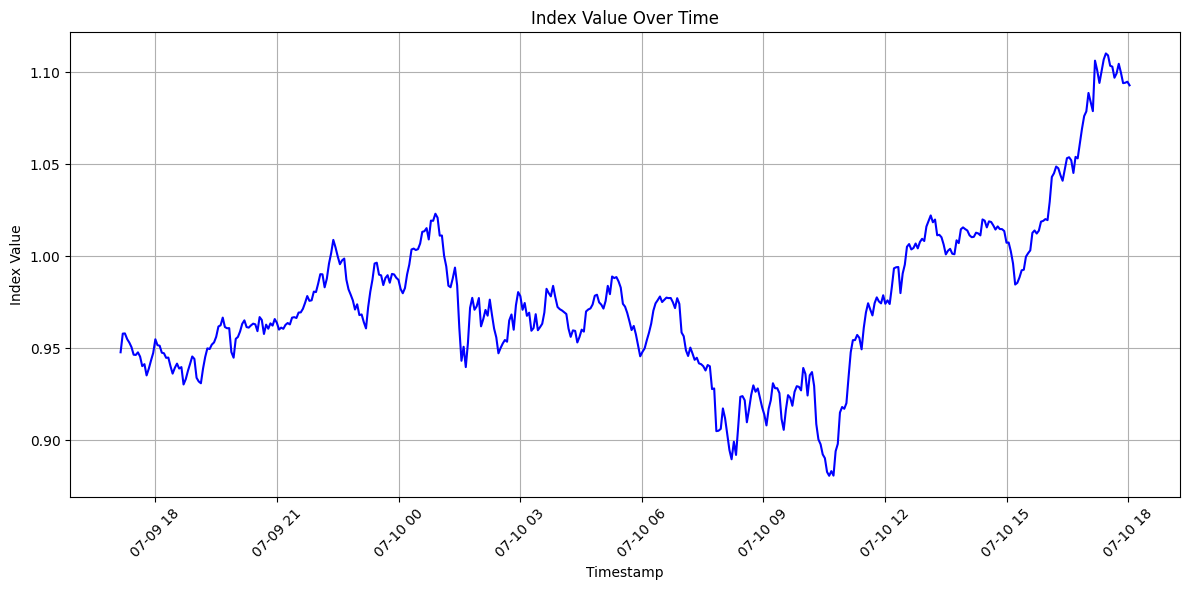

In [54]:
import matplotlib.pyplot as plt

# Ensure the DataFrame is sorted by timestamp
df_set_5 = df_set_5.sort_values(by='timestamp')

# Plotting index_value alone
plt.figure(figsize=(12, 6))
plt.plot(df_set_5['timestamp'], df_set_5['index_value'], linestyle='-', color='blue')
plt.title('Index Value Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Index Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


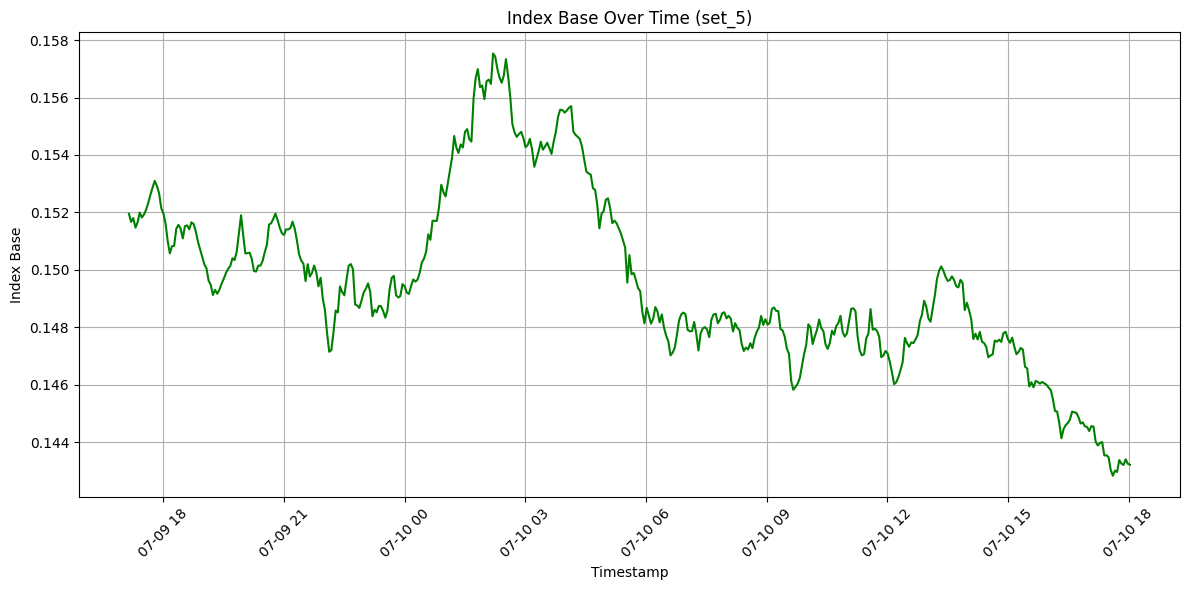

In [55]:
# Plotting index_base alone
plt.figure(figsize=(12, 6))
plt.plot(df_set_5['timestamp'], df_set_5['index_base'], linestyle='-', color='green')
plt.title('Index Base Over Time (set_5)')
plt.xlabel('Timestamp')
plt.ylabel('Index Base')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


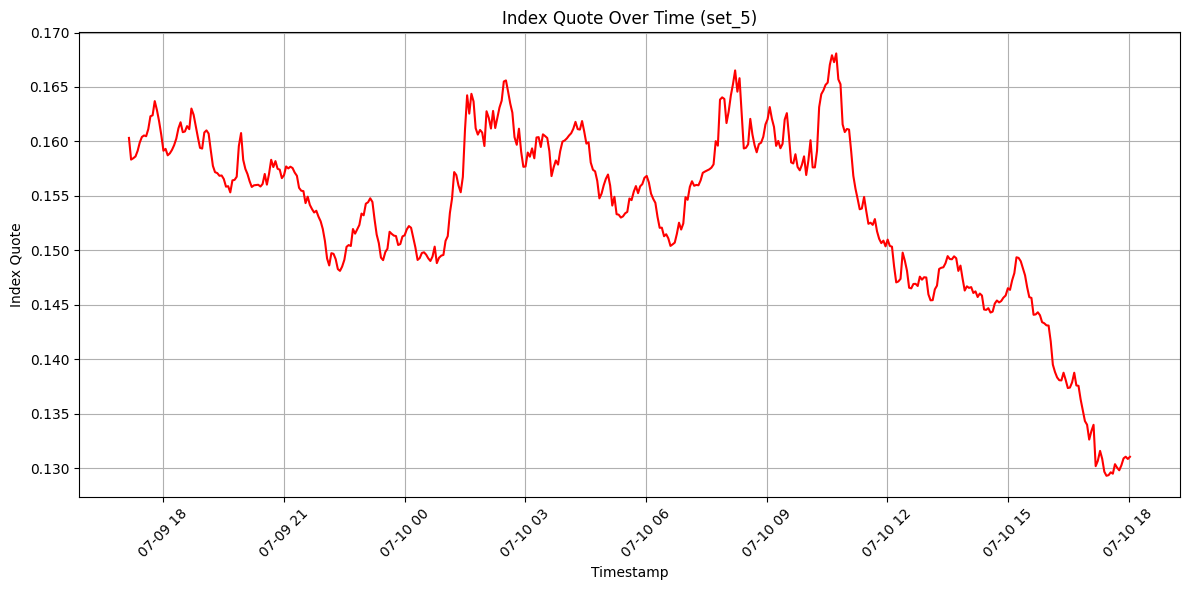

In [56]:
# Plotting index_quote alone
plt.figure(figsize=(12, 6))
plt.plot(df_set_5['timestamp'], df_set_5['index_quote'], linestyle='-', color='red')
plt.title('Index Quote Over Time (set_5)')
plt.xlabel('Timestamp')
plt.ylabel('Index Quote')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Figure 2

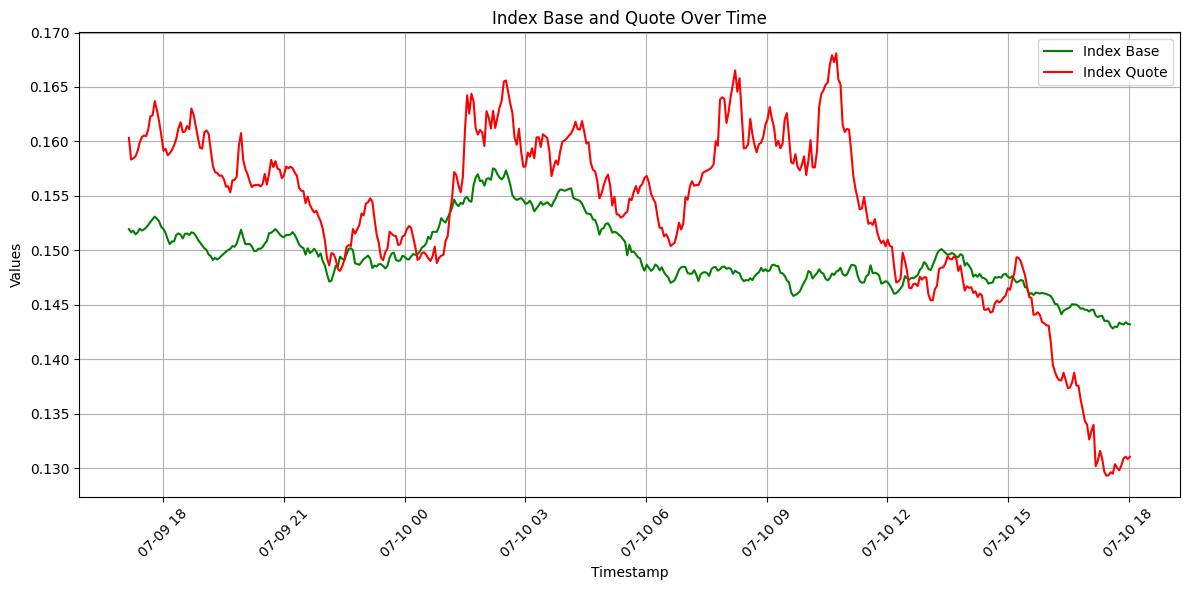

In [57]:
# Combining index_base and index_quote in one chart
plt.figure(figsize=(12, 6))
plt.plot(df_set_5['timestamp'], df_set_5['index_base'], label='Index Base', linestyle='-', color='green')
plt.plot(df_set_5['timestamp'], df_set_5['index_quote'], label='Index Quote', linestyle='-', color='red')
plt.title('Index Base and Quote Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Values')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
# Calculate the correlation between index_base and index_quote
correlation = df_set_5[['index_base', 'index_quote']].corr().iloc[0, 1]

# Display the correlation
print("Correlation between Index Base and Index Quote:")
print(correlation)

Correlation between Index Base and Index Quote:
0.6521790378089161


# Figure 3

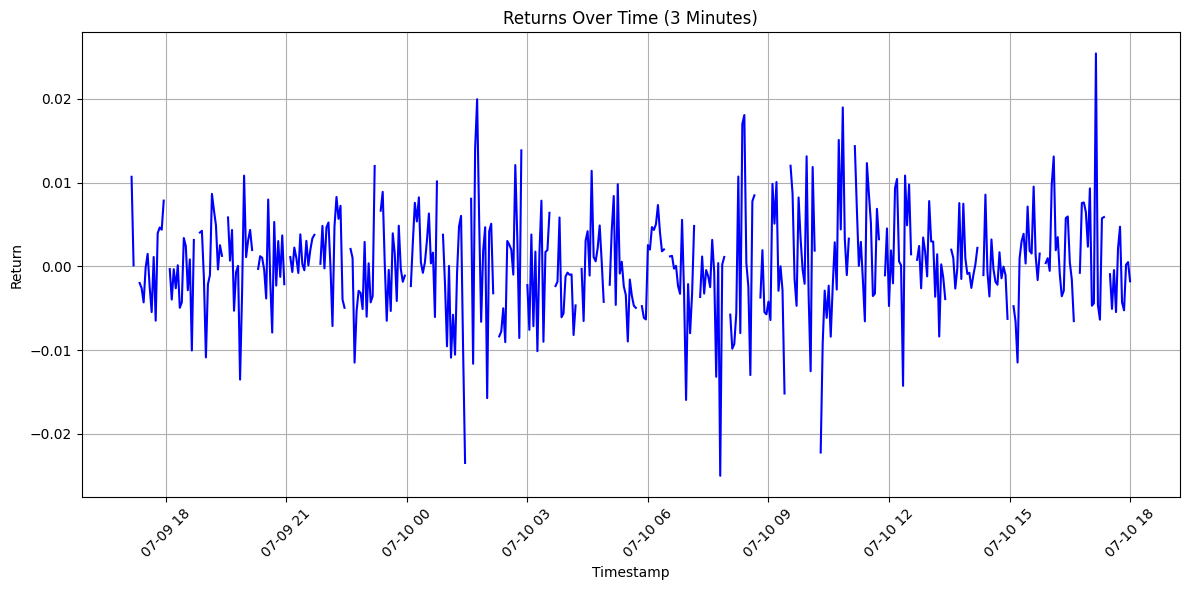

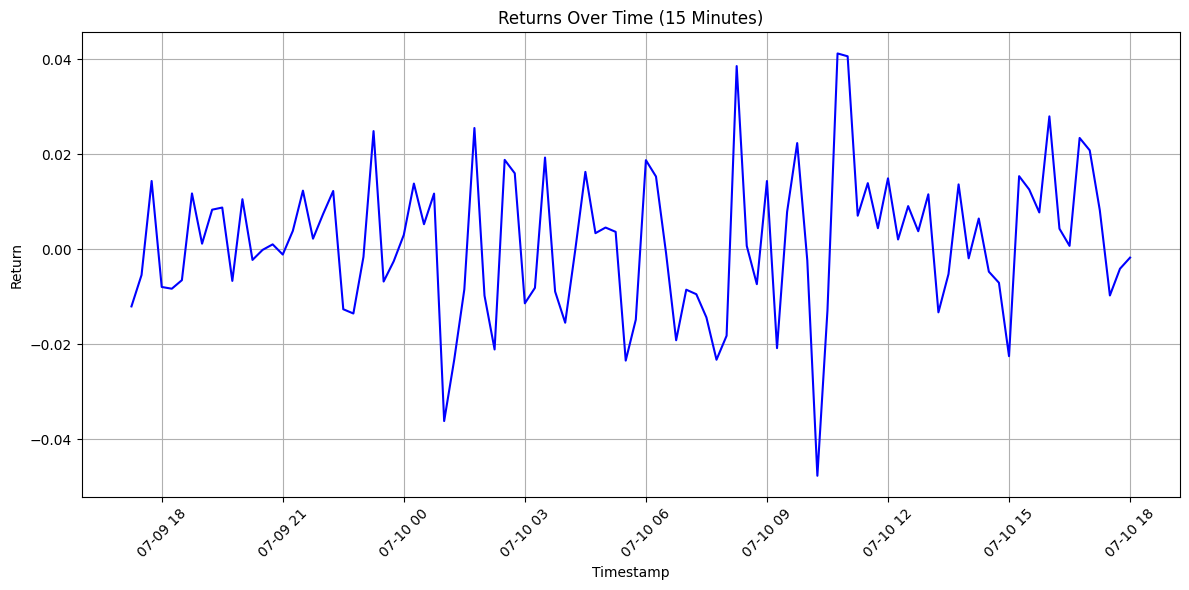

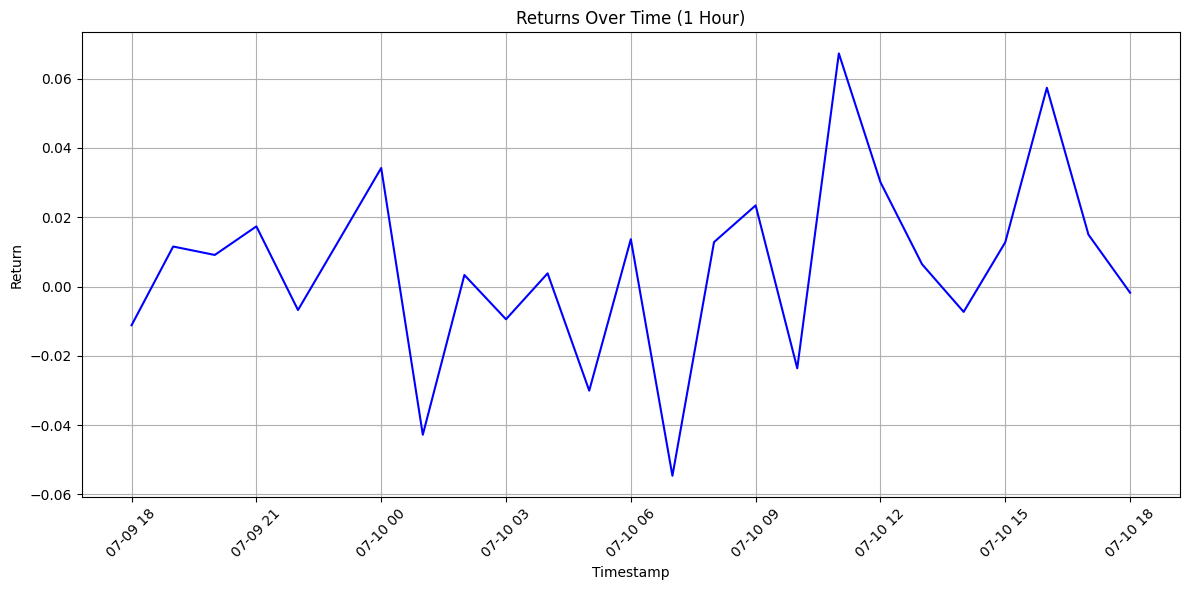

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sort the DataFrame by timestamp
df_set_5 = df_set_5.sort_values(by='timestamp')

# Set the timestamp as the index
df_set_5.set_index('timestamp', inplace=True)

# Drop non-numeric columns before resampling
df_set_5_numeric = df_set_5.drop(columns=['set_name'])

# Function to calculate and plot returns for a given timeframe
def plot_returns(timeframe, label):
    # Resample the data
    df_resampled = df_set_5['index_value'].resample(timeframe).last()
    
    # Calculate the percentage return, explicitly handling NA values
    returns = df_resampled.pct_change(fill_method=None)
    
    # Plotting the returns
    plt.figure(figsize=(12, 6))
    plt.plot(returns.index, returns, linestyle='-', color='blue')
    plt.title(f'Returns Over Time ({label})')
    plt.xlabel('Timestamp')
    plt.ylabel('Return')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Plot returns for 3 minutes, 15 minutes, and 1 hour
plot_returns('3min', '3 Minutes')
plot_returns('15min', '15 Minutes')
plot_returns('1h', '1 Hour')


In [61]:
# Drop non-numeric columns before resampling
df_set_5_numeric = df_set_5.drop(columns=['set_name'])

# Function to calculate total volatility for a given time interval
def calculate_volatility(timeframe):
    # Resample the data
    df_resampled = df_set_5_numeric.resample(timeframe).last()
    
    # Calculate the returns
    df_resampled['return'] = df_resampled['index_value'].pct_change()
    
    # Calculate the total volatility (standard deviation of the returns)
    total_volatility = df_resampled['return'].std()
    
    return total_volatility

# Calculate total volatility for different time intervals
volatility_15min = calculate_volatility('15min')  # 15 minutes
volatility_1hour = calculate_volatility('1h')     # 1 hour
volatility_4hours = calculate_volatility('4h')    # 4 hours

# Display the total volatility for different time intervals
print("Total Volatility of Index Value for 15 Minutes:")
print(volatility_15min)
print("\nTotal Volatility of Index Value for 1 Hour:")
print(volatility_1hour)
print("\nTotal Volatility of Index Value for 4 Hours:")
print(volatility_4hours)


Total Volatility of Index Value for 15 Minutes:
0.015296184661334122

Total Volatility of Index Value for 1 Hour:
0.027155011604445098

Total Volatility of Index Value for 4 Hours:
0.0560197767863162


In [62]:
# Calculate the movement range as a percentage
min_index_value = df_set_5['index_value'].min()
max_index_value = df_set_5['index_value'].max()
movement_range_percentage = ((max_index_value - min_index_value) / min_index_value) * 100

print("Movement Range of Index Value (%):")
print(f"{movement_range_percentage:.2f}%")


Movement Range of Index Value (%):
26.05%


# Figure 4

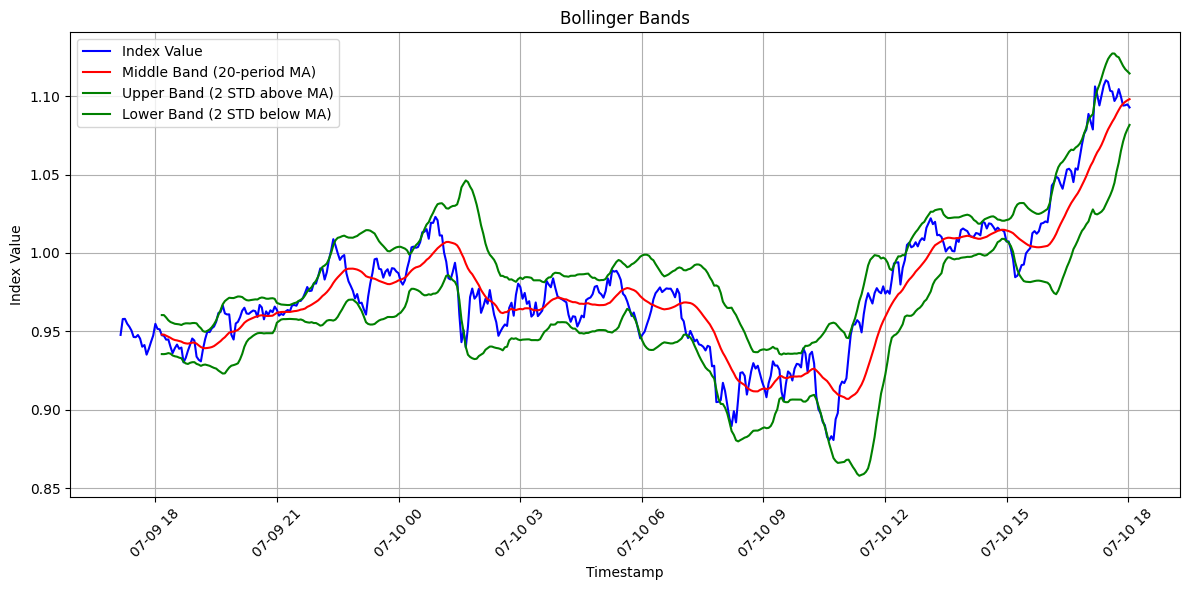

In [63]:
# Calculate the rolling volatility (standard deviation over a rolling window)
df_set_5['rolling_volatility'] = df_set_5['index_value'].pct_change().rolling(window=20).std()

# Calculate Bollinger Bands
df_set_5['middle_band'] = df_set_5['index_value'].rolling(window=20).mean()
df_set_5['upper_band'] = df_set_5['middle_band'] + (df_set_5['index_value'].rolling(window=20).std() * 2)
df_set_5['lower_band'] = df_set_5['middle_band'] - (df_set_5['index_value'].rolling(window=20).std() * 2)

# Plot the Bollinger Bands
plt.figure(figsize=(12, 6))
plt.plot(df_set_5['index_value'], label='Index Value', color='blue')
plt.plot(df_set_5['middle_band'], label='Middle Band (20-period MA)', color='red')
plt.plot(df_set_5['upper_band'], label='Upper Band (2 STD above MA)', color='green')
plt.plot(df_set_5['lower_band'], label='Lower Band (2 STD below MA)', color='green')
plt.title('Bollinger Bands')
plt.xlabel('Timestamp')
plt.ylabel('Index Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
